# Global ChatGPT Student Survey Analysis

## 📌 Study Objective  
This notebook focuses on the computational analysis of global survey data on students’ perceptions and usage patterns of ChatGPT.

The main objective of this research is to investigate a potential behavioral paradox:  
**Are students who report the highest levels of satisfaction with ChatGPT also those who show the least concern about its ethical risks?**

---

## 📚 Data Source and Citation  
The dataset used in this analysis comes from a large-scale global survey examining students’ early perceptions of AI in academic contexts.

- **Title:** Higher Education Students’ Early Perceptions of ChatGPT: Global Survey Data  
- **Publication date:** 5 February 2025  
- **Version:** 2  
- **DOI:** 10.17632/ymg9nsn6kn.2  

---

## 🌍 Survey Overview  
This comprehensive survey was conducted between October 2023 and February 2024 across more than 100 countries. It explores multiple dimensions, including sociodemographic characteristics, usage patterns, perceived technological capabilities, ethical concerns, and overall user satisfaction..
rns.

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
# Get the current working directory
current_folder = os.getcwd()

# Excel file name
file_name = "final dataset.xlsx"

# Build full file path
path = os.path.join(current_folder,"Data", file_name)

# Load the dataset
df = pd.read_excel(path)

# Show first rows
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o,source
0,Afghanistan,2.0,27.0,Afghanistan,القدس المفتوحة,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AR
1,Afghanistan,4.0,100.0,Afghanistan,456,2.0,2.0,3.0,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EN
2,Afghanistan,1.0,21.0,Albania,منيا,1.0,1.0,1.0,1.0,1.0,...,3.0,2.0,3.0,4.0,3.0,2.0,2.0,1.0,1.0,EN
3,Afghanistan,1.0,18.0,Ecuador,"Universidad Indoamerica., Facultad Arquitectur...",2.0,1.0,1.0,1.0,4.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,ES
4,Afghanistan,2.0,26.0,Spain,De vigo universidad,1.0,2.0,2.0,1.0,2.0,...,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,ES


### Creating Unique Identifiers for Respondents

Since the dataset did not have a unique identifier for each individual, 
we created a new column called "Respondent_ID". 

This column assigns a sequential number to each row, ensuring that every respondent 
can be uniquely identified during the analysis and cleaning process.

In [3]:
# Create a  unique identifient for each student
df["Respondent_ID"] = range(1, len(df) + 1)
# Move the Respondent_ID column to the left for better visibility
cols = ["Respondent_ID"] + [col for col in df.columns if col != "Respondent_ID"]
df = df[cols]
df.head()

,Respondent_ID,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o,source
0,1,Afghanistan,2.0,27.0,Afghanistan,القدس المفتوحة,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AR
1,2,Afghanistan,4.0,100.0,Afghanistan,456,2.0,2.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EN
2,3,Afghanistan,1.0,21.0,Albania,منيا,1.0,1.0,1.0,1.0,...,3.0,2.0,3.0,4.0,3.0,2.0,2.0,1.0,1.0,EN
3,4,Afghanistan,1.0,18.0,Ecuador,"Universidad Indoamerica., Facultad Arquitectur...",2.0,1.0,1.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,ES
4,5,Afghanistan,2.0,26.0,Spain,De vigo universidad,1.0,2.0,2.0,1.0,...,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,ES


In [4]:
print(df.shape[0])
print(df.shape[1])

23218
175


### Selecting Columns for the Study

The original dataset is organized into ten sections covering different aspects of students’ interaction with ChatGPT.  
However, to keep the analysis focused and aligned with the research objective, only the sections most relevant to the study were selectedol.

For this reason, the analysis focuses on the following sections:

- **Section 1 – Socio-demographic information**, to understand the background of respondents.
- **Section 2 – Usage of ChatGPT**, to analyze how students interact with the tool and for what purposes.
- **Section 4 – Regulation and ethical concerns**, to examine perceptions of risks, responsibility, and institutional regulation.
- **Section 5 – Satisfaction and attitudes**, to evaluate students’ satisfaction and perceived importance of AI tools in their academic environment.

These sections provide the key variables needed to investigate the relationship between **ChatGPT usage, ethical perceptions, and user satisfaction**.

In [5]:

# Section 1: Sociodemographic (excluding Q5 and Q9)
s1 = ['Q1', 'Q2','Q4','Q6', 'Q7', 'Q8', 'Q10', 'Q11', 'Q12']

# Section 2: Usage (Q13-Q17 + Q18a-Q18l)
s2 = [f"Q{i}" for i in range(13,18)] + [f"Q18{o}" for o in "abcdefghijkl"]
# Section 4: Regulation and Ethical Concerns
s4 = ["Q20"] + [f"Q21{p}" for p in "abcd"] + [f"Q22{q}" for q in "abcdefghij"]+[f"Q23{r}" for r in "abcd"]

# Section 5: Satisfaction and Attitude (
s5 = [f"Q24{s}" for s in "abcdefg"] +[f"Q25{u}" for u in "abcd"]


In [6]:
# Combine all columns we need
cols_to_keep = ["Respondent_ID"] + s1 + s2 + s4 + s5 
#Create a new dataframe with only selected columns
df_selected = df[cols_to_keep].copy()
df_selected.head()


,Respondent_ID,Q1,Q2,Q4,Q6,Q7,Q8,Q10,Q11,Q12,...,Q24b,Q24c,Q24d,Q24e,Q24f,Q24g,Q25a,Q25b,Q25c,Q25d
0,1,Afghanistan,2.0,Afghanistan,1.0,1.0,1.0,1.0,1.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Afghanistan,4.0,Afghanistan,2.0,2.0,3.0,4.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Afghanistan,1.0,Albania,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,4.0,3.0,3.0,2.0,3.0,3.0,3.0,3.0
3,4,Afghanistan,1.0,Ecuador,2.0,1.0,1.0,4.0,1.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Afghanistan,2.0,Spain,1.0,2.0,2.0,2.0,3.0,3.0,...,2.0,4.0,2.0,4.0,4.0,4.0,4.0,5.0,5.0,3.0


In [7]:
print(df_selected.shape[0])
print(df_selected.shape[1])

23218
57


### Filtering the Dataset to Keep Only ChatGPT Users

To ensure that the analysis focuses only on relevant respondents,
we keep only participants who reported having used ChatGPT.

In [8]:
df_selected = df_selected[df_selected["Q13"].fillna(0) == 1].copy()
print(df_selected.shape[0])
print(df_selected.shape[1])
df_selected.head()

16010
57


,Respondent_ID,Q1,Q2,Q4,Q6,Q7,Q8,Q10,Q11,Q12,...,Q24b,Q24c,Q24d,Q24e,Q24f,Q24g,Q25a,Q25b,Q25c,Q25d
0,1,Afghanistan,2.0,Afghanistan,1.0,1.0,1.0,1.0,1.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Afghanistan,1.0,Albania,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,4.0,3.0,3.0,2.0,3.0,3.0,3.0,3.0
4,5,Afghanistan,2.0,Spain,1.0,2.0,2.0,2.0,3.0,3.0,...,2.0,4.0,2.0,4.0,4.0,4.0,4.0,5.0,5.0,3.0
6,7,Afghanistan,2.0,Turkey,1.0,1.0,1.0,2.0,1.0,4.0,...,3.0,3.0,4.0,4.0,4.0,3.0,4.0,4.0,2.0,2.0
7,8,Afghanistan,2.0,Turkey,1.0,1.0,1.0,1.0,1.0,3.0,...,5.0,5.0,3.0,5.0,5.0,5.0,4.0,4.0,5.0,4.0


In [9]:
df_selected["Q13"].isnull().sum()

0

### Data Preparation and Structuring

The original dataset was reorganized into thematic dimension tables (df_socio, df_usage, df_ethic, df_satisfaction) to improve clarity and facilitate analysis.  

Each table captures a specific aspect of the study and can be linked using the common key "Respondent_ID".  

Composite variables (indices) were created by averaging multiple related items in order to measure broader constructs such as usage patterns, ethical concerns, regulation needs, and satisfaction levels.  

A minimum response threshold (approximately 75%) was applied to ensure the reliability of these indices. Otherwise, missing values (NaN) were retained.  

Survey variables originally labeled as Q1 to Q25 were renamed into meaningful and interpretable column names (e.g., Gender, Study_Level, etc.), improving readability, analysis, and visualization, especially for BI tools.  

The final structure distinguishes between categorical variables (dimensions) and numerical indicators (facts).  

This aligns the dataset with a dimensional modeling approach suitable for statistical analysis and data visualization.sis and data visualization.tion.


In [10]:
# Section 1 : Sociodemographic 
s1 = ['Q1', 'Q2', 'Q4', 'Q6', 'Q7', 'Q8', 'Q10', 'Q11', 'Q12']
df_socio = df_selected[["Respondent_ID"] + s1].copy()


# Rename columns
df_socio.rename(columns={
    'Q1': 'Citizenship',
    'Q2': 'Gender',
    'Q4': 'Study_Country',
    'Q6': 'Institution_Public',
    'Q7': 'Student_Status',
    'Q8': 'Study_Level',
    'Q10': 'Field_of_Study',
    'Q11': 'Learning_Method',
    'Q12': 'Job_Confidence'
}, inplace=True)
df_socio.head()

,Respondent_ID,Citizenship,Gender,Study_Country,Institution_Public,Student_Status,Study_Level,Field_of_Study,Learning_Method,Job_Confidence
0,1,Afghanistan,2.0,Afghanistan,1.0,1.0,1.0,1.0,1.0,3.0
2,3,Afghanistan,1.0,Albania,1.0,1.0,1.0,1.0,1.0,1.0
4,5,Afghanistan,2.0,Spain,1.0,2.0,2.0,2.0,3.0,3.0
6,7,Afghanistan,2.0,Turkey,1.0,1.0,1.0,2.0,1.0,4.0
7,8,Afghanistan,2.0,Turkey,1.0,1.0,1.0,1.0,1.0,3.0


In [11]:

# Section 2: Usage of ChatGPT

# 1. Rename original columns Q13-Q17
df_selected.rename(columns={
    'Q13': 'Used_ChatGPT',
    'Q14': 'ChatGPT_Version',
    'Q15': 'General_Usage_Frequency',
    'Q16': 'Experience_with_ChatGPT',
    'Q17': 'First_Exposure_ChatGPT'
}, inplace=True)


# 2. Create composite indices for Q18a–Q18l with a minimum of 3 valid responses

# Academic usage (4 items)
cols_acad = ["Q18a", "Q18d", "Q18i", "Q18k"]
df_selected['Academic_Usage_Index'] = (
    df_selected[cols_acad]
    .mean(axis=1)  # compute the row-wise mean
    .where(df_selected[cols_acad].notna().sum(axis=1) >= 3)  
    # keep the result only if at least 2 responses are available
)

# Professional usage (2 items)
cols_prof = ['Q18b', 'Q18l']
df_selected['Professional_Usage_Index'] = (
    df_selected[cols_prof]
    .mean(axis=1)
    .where(df_selected[cols_prof].notna().sum(axis=1) >= 2)
)

# Creative usage (3 items)
cols_crea = ['Q18c', 'Q18e', 'Q18g']
df_selected['Creative_Usage_Index'] = (
    df_selected[cols_crea]
    .mean(axis=1)
    .where(df_selected[cols_crea].notna().sum(axis=1) >= 2)
)

# Personal usage (3 items)
cols_perso = ['Q18f', 'Q18h', 'Q18j']
df_selected['Personal_Usage_Index'] = (
    df_selected[cols_perso]
    .mean(axis=1)
    .where(df_selected[cols_perso].notna().sum(axis=1) >= 2)
)


# 4. Preview the renamed variables
df_usage = df_selected[["Respondent_ID",
             "Used_ChatGPT",
             "ChatGPT_Version",
             "General_Usage_Frequency",
             "Experience_with_ChatGPT",
             "First_Exposure_ChatGPT",
             "Academic_Usage_Index",
             "Professional_Usage_Index",
             "Creative_Usage_Index",
             "Personal_Usage_Index"]]
df_usage.head()

,Respondent_ID,Used_ChatGPT,ChatGPT_Version,General_Usage_Frequency,Experience_with_ChatGPT,First_Exposure_ChatGPT,Academic_Usage_Index,Professional_Usage_Index,Creative_Usage_Index,Personal_Usage_Index
0,1,1.0,2.0,3.0,4.0,2.0,3.75,4.0,3.000000,4.000000
2,3,1.0,1.0,2.0,1.0,2.0,1.75,1.5,2.333333,1.666667
4,5,1.0,1.0,3.0,4.0,4.0,3.25,3.5,3.000000,3.000000
6,7,1.0,1.0,1.0,4.0,4.0,2.00,1.0,1.666667,1.333333
7,8,1.0,1.0,2.0,5.0,2.0,3.25,1.5,2.333333,2.333333


In [12]:
# Section 4: Regulation and Ethical Concerns

# Rename Q20 column
df_selected.rename(columns={
    "Q20": "Institutional_AI_Policy"
}, inplace=True)

# Composite variables with missing data handling
# AI Regulation Need (4 items) : require at least 3 responses (75%)
cols_regulation = ["Q21a","Q21b","Q21c", "Q21d"]
df_selected["AI_Regulation_Need"] = df_selected[cols_regulation].mean(axis=1).where(
    df_selected[cols_regulation].notna().sum(axis=1) >= 3
)

# Define columns for each dimension
academic_cols = ["Q22a", "Q22b", "Q22c", "Q22j"]          # Academic and ethical risk items
info_cols = ["Q22e", "Q22d"]                               # Information reliability risk items
social_cols = ["Q22g", "Q22i", "Q22h"]                     # Social impact risk items
privacy_cols = ["Q22f"]                                    # Privacy concern (single item)

# Academic_Ethical_Risk: mean of items, require at least 3 responses (75% of 4)
df_selected["Academic_Ethical_Risk"] = df_selected[academic_cols].mean(axis=1).where(
    df_selected[academic_cols].notna().sum(axis=1) >= 3
)

# Information_Reliability_Risk: mean of items, require both responses (75% of 2 → round up)
df_selected["Information_Reliability_Risk"] = df_selected[info_cols].mean(axis=1).where(
    df_selected[info_cols].notna().sum(axis=1) >= 2
)

# Social_Impact_Risk: mean of items, require at least 2 responses (75% of 3 → round up)
df_selected["Social_Impact_Risk"] = df_selected[social_cols].mean(axis=1).where(
    df_selected[social_cols].notna().sum(axis=1) >= 2
)

# Privacy_Concern: single item, no threshold needed
df_selected["Privacy_Concern"] = df_selected["Q22f"]

# Student Ethical Engagement (4 items) : require at least 3 responses (75%)
cols_ethics = ["Q23a", "Q23b", "Q23c","Q23d"]
df_selected["Student_Ethical_Engagement"] = df_selected[cols_ethics].mean(axis=1).where(
    df_selected[cols_ethics].notna().sum(axis=1) >= 3
)

df_ethic = df_selected[["Respondent_ID",
    "Institutional_AI_Policy",
    "AI_Regulation_Need",
    "Academic_Ethical_Risk",
    "Information_Reliability_Risk",
    "Social_Impact_Risk",
    "Privacy_Concern",
    "Student_Ethical_Engagement"
]]
df_ethic.head()

,Respondent_ID,Institutional_AI_Policy,AI_Regulation_Need,Academic_Ethical_Risk,Information_Reliability_Risk,Social_Impact_Risk,Privacy_Concern,Student_Ethical_Engagement
0,1,2.0,2.50,3.00,3.0,3.000000,3.0,2.50
2,3,1.0,2.00,2.00,1.5,1.666667,2.0,1.25
4,5,3.0,4.00,2.50,2.0,1.666667,1.0,2.25
6,7,3.0,3.25,2.50,2.0,2.000000,2.0,3.00
7,8,2.0,2.25,3.25,2.5,3.666667,3.0,3.25


In [13]:
# Section 5: Satisfaction and Attitude

# Satisfaction Index (Q24a to Q24g) : require at least 5 out of 7 responses (~71%, close to 75%)
cols_q24 = [f"Q24{s}" for s in "abcdefg"]
df_selected["Satisfaction_Index"] = df_selected[cols_q24].mean(axis=1).where(
    df_selected[cols_q24].notna().sum(axis=1) >= 5
)

# Perceived Control & Importance Index (Q25a to Q25d) : require at least 3 out of 4 responses (75%)
cols_q25 = [f"Q25{s}" for s in "abcd"]
df_selected["Perceived_Control_Importance_Index"] = df_selected[cols_q25].mean(axis=1).where(
    df_selected[cols_q25].notna().sum(axis=1) >= 3
)

# Verification
df_satisfaction = df_selected[["Respondent_ID", "Satisfaction_Index", "Perceived_Control_Importance_Index"]]
df_satisfaction.head()


,Respondent_ID,Satisfaction_Index,Perceived_Control_Importance_Index
0,1,NaN,NaN
2,3,2.142857,3.00
4,5,3.428571,4.25
6,7,3.571429,3.00
7,8,4.714286,4.25


### Categorical Variables Transformation

In this step, numerical survey responses are transformed into categorical variables 
to improve interpretability and readability of the dataset.

Several variables initially coded with numeric values (e.g., 1, 2, 3, etc.) are mapped 
to meaningful labels (e.g., "Male", "Female", "Yes", "No", etc.). This transformation 
facilitates data analysis, visualization, and interpretation, particularly when using 
business intelligence tools such as Power BI.

Each transformation is applied consistently across the different dimension tables 
(df_socio, df_usage, df_ethic), ensuring a structured and coherent dataset.

The resulting variables are also converted into categorical data types to optimize 
memory usage and enhance analytical performance.

In [14]:
# Create clean copies of all dimension tables
df_socio = df_socio.copy()
df_usage = df_usage.copy()
df_ethic = df_ethic.copy()
df_satisfaction = df_satisfaction.copy()


In [15]:

mappings_socio = {
    'Gender': {1: 'Male', 2: 'Female', 3: 'Other', 4: 'Prefer not to say'},
    'Institution_Public': {1: 'Yes', 2: 'No'},
    'Student_Status': {1: 'Full-time', 2: 'Part-time'},
    'Study_Level': {1: "Undergraduate (Bachelor's)", 2: "Postgraduate (Master's)", 3: "Doctoral degree"},
    'Field_of_Study': {1: 'Arts and Humanities', 2: 'Social Sciences', 3: 'Applied Sciences', 4: 'Natural and Life Sciences'},
    'Learning_Method': {1: 'Traditional (Classroom)', 2: 'Online', 3: 'Blended (Hybrid)'},
    'Job_Confidence': {1: 'Not at all confident', 2: 'Slightly confident', 3: 'Moderately confident', 4: 'Very confident', 5: 'Extremely confident'},
}

for col, map_dict in mappings_socio.items():
    if col in df_socio.columns:
        df_socio[col] = df_socio[col].map(map_dict).astype('category')



In [16]:
mappings_usage = {
    'Used_ChatGPT': {1: "Yes", 2: "No"},
    'ChatGPT_Version': {1: 'ChatGPT-3.5', 2: 'ChatGPT-4', 3: 'Both'},
    'General_Usage_Frequency': {1: "Rarely", 2: "Occasionally", 3: "Moderately", 4: "Considerably", 5: 'Extensively'},
    'Experience_with_ChatGPT': {1: "Very bad", 2: "Bad", 3: "Neutral", 4: "Good", 5: "Very good"},
    'First_Exposure_ChatGPT': {1: "Mainstream media", 2: "Social media", 3: "Class/Work", 4: "Friends/Family"},
}

for col, map_dict in mappings_usage.items():
    if col in df_usage.columns:
        df_usage[col] = df_usage[col].map(map_dict).astype('category')

In [17]:
mappings_ethic = {
    'Institutional_AI_Policy': {1: "Yes", 2: "No", 3: "I don't know"}
}


for col, map_dict in mappings_ethic.items():
    if col in df_ethic.columns:
        df_ethic[col] = df_ethic[col].map(map_dict).astype('category')

In [18]:
# Function to display structure of each dataframe
def check_dataframe(df, name):
    print(f"\n{name}")
    print("-" * 40)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)
    print("\nPreview:")
    print(df.head())


# Check all tables
check_dataframe(df_socio, "df_socio")
check_dataframe(df_usage, "df_usage")
check_dataframe(df_ethic, "df_ethic")
check_dataframe(df_satisfaction, "df_satisfaction")


df_socio
----------------------------------------
Shape: (16010, 10)

Columns:
['Respondent_ID', 'Citizenship', 'Gender', 'Study_Country', 'Institution_Public', 'Student_Status', 'Study_Level', 'Field_of_Study', 'Learning_Method', 'Job_Confidence']

Data types:
Respondent_ID            int64
Citizenship             object
Gender                category
Study_Country           object
Institution_Public    category
Student_Status        category
Study_Level           category
Field_of_Study        category
Learning_Method       category
Job_Confidence        category
dtype: object

Preview:
   Respondent_ID  Citizenship  Gender Study_Country Institution_Public  \
0              1  Afghanistan  Female   Afghanistan                Yes   
2              3  Afghanistan    Male       Albania                Yes   
4              5  Afghanistan  Female         Spain                Yes   
6              7  Afghanistan  Female        Turkey                Yes   
7              8  Afghanistan  Fe

### Exploring ChatGPT Usage, Satisfaction, and Ethical Perceptions

In this section, we aim to analyze the respondents’ use of ChatGPT and how it relates to their satisfaction and ethical perceptions. 

Specifically, we will:

1. **Check ChatGPT usage distribution** – see what proportion of respondents have used ChatGPT.  
2. **Compute average satisfaction by categories** – compare satisfaction across key demographics such as field of study, gender, and study level.  
3. **Examine correlations** – investigate the relationship between satisfaction and ethical concerns, including AI risk perception and student engagement in ethical considerations.  


This analysis helps understand not only who uses ChatGPT, but also how satisfaction may influence perceptions of ethics and risk.

--- Complete Pearson Correlation Matrix ---


,Satisfaction_Index,Academic_Ethical_Risk,Information_Reliability_Risk,Social_Impact_Risk,Privacy_Concern,Student_Ethical_Engagement
Satisfaction_Index,1.000000,-0.114495,-0.200466,0.053798,-0.103928,-0.060456
Academic_Ethical_Risk,-0.114495,1.000000,0.759161,0.541423,0.530947,0.330140
Information_Reliability_Risk,-0.200466,0.759161,1.000000,0.467399,0.573522,0.300703
Social_Impact_Risk,0.053798,0.541423,0.467399,1.000000,0.535048,0.244491
Privacy_Concern,-0.103928,0.530947,0.573522,0.535048,1.000000,0.240964
Student_Ethical_Engagement,-0.060456,0.330140,0.300703,0.244491,0.240964,1.000000


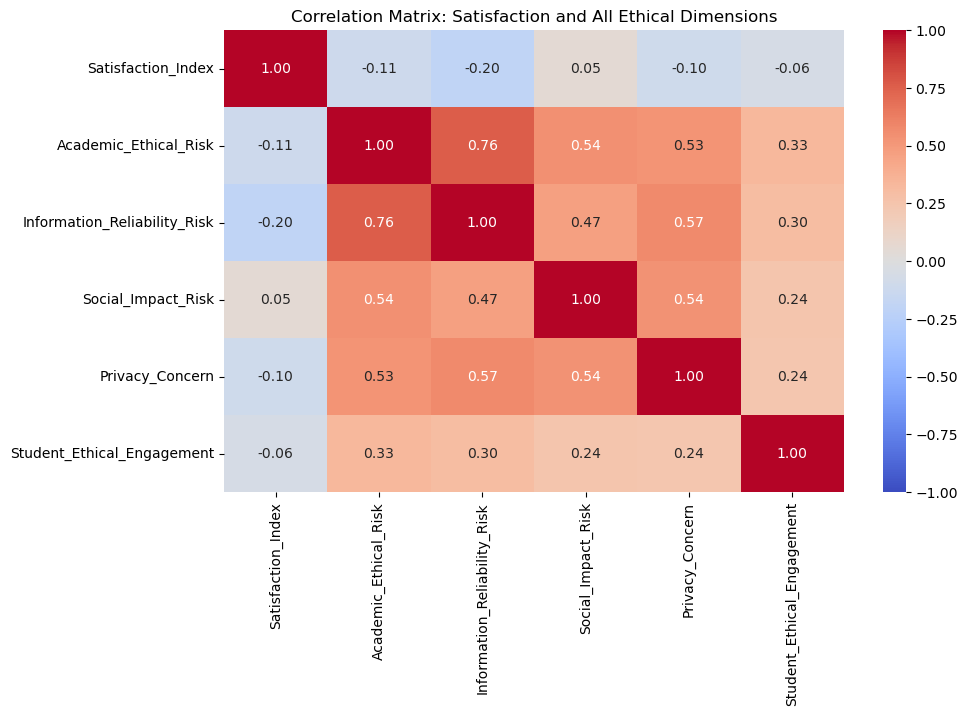

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select all dimensions of interest (adding Privacy_Concern here)
indices_cols = [
    "Satisfaction_Index",
    "Academic_Ethical_Risk",
    "Information_Reliability_Risk",
    "Social_Impact_Risk",
    "Privacy_Concern",  # Adding your specific variable
    "Student_Ethical_Engagement",
]

# 2. Compute the Pearson correlation matrix
correlation_matrix = df_selected[indices_cols].corr()

# 3. Display the complete numerical table
print("--- Complete Pearson Correlation Matrix ---")
display(correlation_matrix)

# 4. Visual bonus: Display a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1
)
plt.title("Correlation Matrix: Satisfaction and All Ethical Dimensions")
plt.show()


In [20]:
 # Convert  Citizenship and Study_Country to categorical type
df_socio['Citizenship'] = df_socio['Citizenship'].astype('category')
df_socio['Study_Country'] = df_socio['Study_Country'].astype('category')
# Verification: check the data types
df_selected.dtypes

Respondent_ID                           int64
Q1                                     object
Q2                                    float64
Q4                                     object
Q6                                    float64
                                       ...   
Social_Impact_Risk                    float64
Privacy_Concern                       float64
Student_Ethical_Engagement            float64
Satisfaction_Index                    float64
Perceived_Control_Importance_Index    float64
Length: 69, dtype: object

### Replace missing values in categorical columns

In this step, we replace all empty or missing values (`NaN`) in the categorical columns with `"N/A"`.  
This ensures that in Power BI, the blanks are displayed as a visible category in charts and slicers instead of being ignored.  

Numeric columns are left unchanged so that calculations (e.g., averages) can still be performed correctly.

In [21]:
# List of all tables
tables = [df_socio, df_usage, df_ethic, df_satisfaction]

for df in tables:
    for col in df.columns:
        # Vérifie si la colonne est catégorielle
        if str(df[col].dtype) == "category":
            # Ajouter "N/A" aux catégories si elle n'existe pas encore
            if "N/A" not in df[col].cat.categories:
                df[col] = df[col].cat.add_categories("N/A")
            # Remplacer les NaN par "N/A"
            df[col] = df[col].fillna("N/A")

# Vérification rapide : afficher les valeurs manquantes après remplacement
for df, name in zip(tables, ["df_socio", "df_usage", "df_ethic", "df_satisfaction"]):
    print(f"Missing values in categorical columns of {name}:")
    print(df.select_dtypes('category').isna().sum())
    print("-"*40)

Missing values in categorical columns of df_socio:
Citizenship           0
Gender                0
Study_Country         0
Institution_Public    0
Student_Status        0
Study_Level           0
Field_of_Study        0
Learning_Method       0
Job_Confidence        0
dtype: int64
----------------------------------------
Missing values in categorical columns of df_usage:
Used_ChatGPT               0
ChatGPT_Version            0
General_Usage_Frequency    0
Experience_with_ChatGPT    0
First_Exposure_ChatGPT     0
dtype: int64
----------------------------------------
Missing values in categorical columns of df_ethic:
Institutional_AI_Policy    0
dtype: int64
----------------------------------------
Missing values in categorical columns of df_satisfaction:
Series([], dtype: float64)
----------------------------------------


### Export the tables

In [22]:
current_folder = os.getcwd()

# Export each table to CSV 
df_socio.to_csv(os.path.join(current_folder, "data", "df_socio.csv"), index=False)
df_usage.to_csv(os.path.join(current_folder, "data", "df_usage.csv"), index=False)
df_ethic.to_csv(os.path.join(current_folder, "data", "df_ethic.csv"), index=False)
df_satisfaction.to_csv(os.path.join(current_folder, "data", "df_satisfaction.csv"), index=False)
print("The 4 CSV files have been successfully exported to:", current_folder)


The 4 CSV files have been successfully exported to: C:\Users\SANDRINE\Documents\Higher education Students
